In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/reihanenamdari/breast-cancer/Breast_Cancer.csv


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv("/kaggle/input/datasets/reihanenamdari/breast-cancer/Breast_Cancer.csv")

In [39]:
df.shape

(4024, 16)

In [40]:
df.head(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
5,51,White,Single,T1,N1,IIA,Moderately differentiated,2,Regional,20,Positive,Positive,18,2,89,Alive
6,51,White,Married,T1,N1,IIA,Well differentiated,1,Regional,8,Positive,Positive,11,1,54,Alive
7,40,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,9,1,14,Dead
8,40,White,Divorced,T4,N3,IIIC,Poorly differentiated,3,Regional,103,Positive,Positive,20,18,70,Alive
9,69,White,Married,T4,N3,IIIC,Well differentiated,1,Distant,32,Positive,Positive,21,12,92,Alive


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [42]:
df.columns


Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')

In [43]:
df.drop(columns=['Race', 'Marital Status','6th Stage','differentiate','Regional Node Examined','Survival Months'],inplace = True)

In [44]:
df.columns


Index(['Age', 'T Stage ', 'N Stage', 'Grade', 'A Stage', 'Tumor Size',
       'Estrogen Status', 'Progesterone Status', 'Reginol Node Positive',
       'Status'],
      dtype='object')

In [45]:
df.head()

,Age,T Stage,N Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Reginol Node Positive,Status
0,68,T1,N1,3,Regional,4,Positive,Positive,1,Alive
1,50,T2,N2,2,Regional,35,Positive,Positive,5,Alive
2,58,T3,N3,2,Regional,63,Positive,Positive,7,Alive
3,58,T1,N1,3,Regional,18,Positive,Positive,1,Alive
4,47,T2,N1,3,Regional,41,Positive,Positive,1,Alive


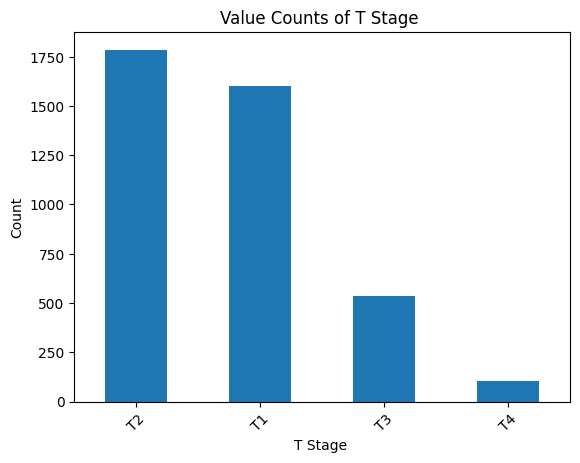

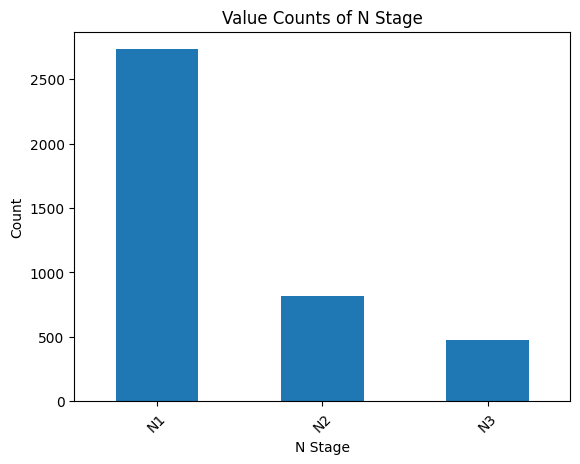

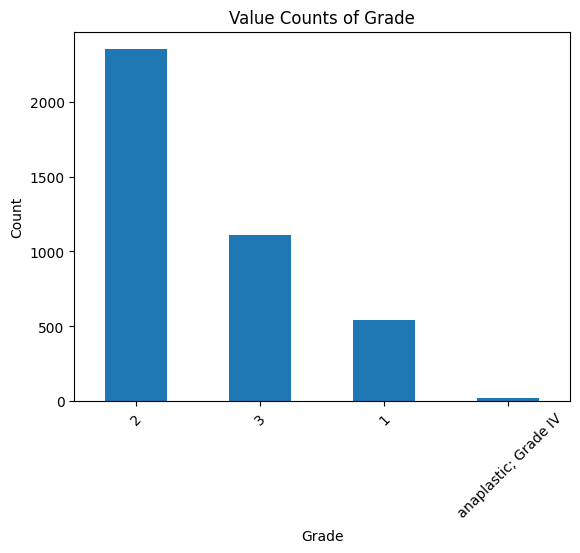

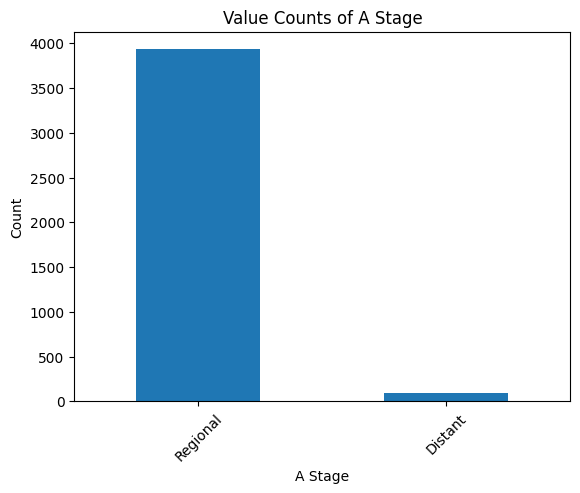

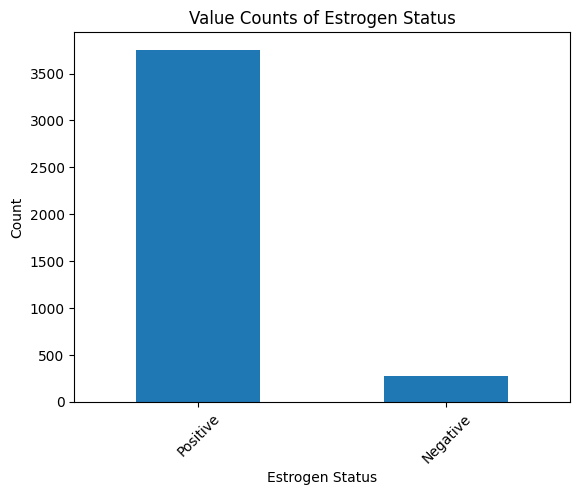

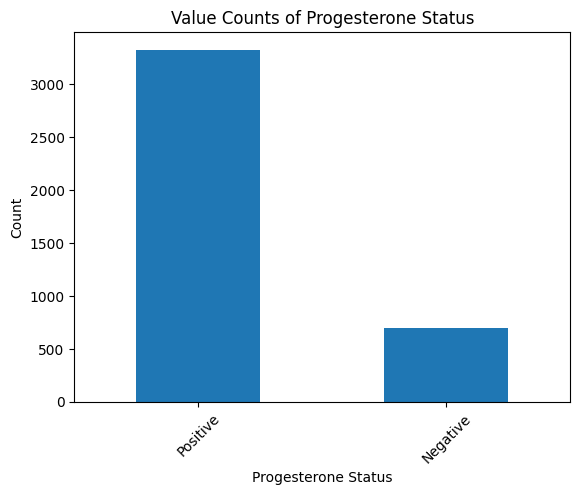

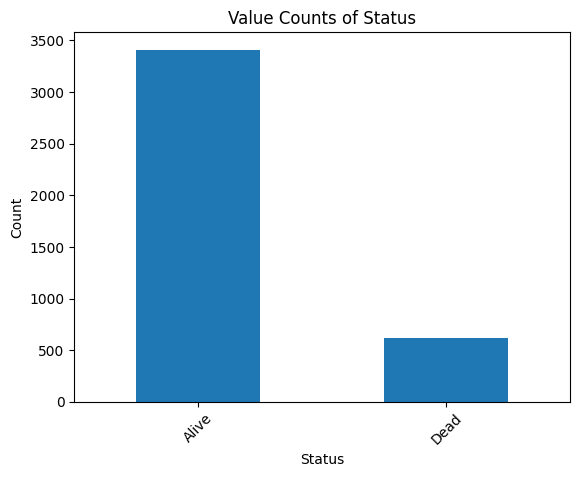

In [46]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Value Counts of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

In [47]:
df["T Stage "] = df["T Stage "].str.replace("T", "").astype(int)
df["N Stage"] = df["N Stage"].str.replace("N", "").astype(int)

In [48]:
df.head()

,Age,T Stage,N Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Reginol Node Positive,Status
0,68,1,1,3,Regional,4,Positive,Positive,1,Alive
1,50,2,2,2,Regional,35,Positive,Positive,5,Alive
2,58,3,3,2,Regional,63,Positive,Positive,7,Alive
3,58,1,1,3,Regional,18,Positive,Positive,1,Alive
4,47,2,1,3,Regional,41,Positive,Positive,1,Alive


In [49]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [50]:
X = df.drop("Status", axis=1)   # Features
y = df["Status"]               # Target (Alive / Dead)

In [51]:
df.head()

,Age,T Stage,N Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Reginol Node Positive,Status
0,68,1,1,3,1,4,1,1,1,0
1,50,2,2,2,1,35,1,1,5,0
2,58,3,3,2,1,63,1,1,7,0
3,58,1,1,3,1,18,1,1,1,0
4,47,2,1,3,1,41,1,1,1,0


In [52]:


# Check if mapping worked
print(df["Status"].unique())
print(df["Status"].isnull().sum())  # should be 0

# ---- FEATURES & TARGET ----
X = df.drop("Status", axis=1)
y = df["Status"]

# ---- TRAIN TEST SPLIT ----
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- SCALING ----
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ---- MODEL ----
from sklearn.naive_bayes import GaussianNB
model = GaussianNB(priors=[0.5, 0.5])
model.fit(X_train, y_train)

[0 1]
0


GaussianNB(priors=[0.5, 0.5])

In [53]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8024844720496894
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       685
           1       0.37      0.46      0.41       120

    accuracy                           0.80       805
   macro avg       0.64      0.66      0.65       805
weighted avg       0.82      0.80      0.81       805

